# DS4DS Exercise Sheet 01

**General Instructions:**

- Review the weekly course material (lectures, readings, slides, etc.) before starting the exercises.
- Complete all assigned exercises independently before the Q&A session.
- Please use Julia Version 1.10.x to ensure compatibility.
- Please only write between the `#--- YOUR CODE STARTS HERE ---#` and `#--- YOUR CODE ENDS HERE ---#` comments.

We have the two matrices $A$, $B$:

$
A = \begin{bmatrix} 0 & 0 \\ 2 & 0 \end{bmatrix}, \\
B = \begin{bmatrix} 0 & -1 \\ 4 & 0 \end{bmatrix}
$

In [1]:
A = [0 0; 2 0]

B = [0 -1; 4 0]

2×2 Matrix{Int64}:
 0  -1
 4   0

### Task 1: Calculate the eigenvalues of the matrices $A$,$B$ and assign them to *eig_A* and *eig_B* 
**Hint:** You should calculate them by hand and insert them here. Alternatively, you may solve this in Julia, but without the use of any extra packages.

In [2]:
eig_A = 0
eig_B = 0

### BEGIN SOLUTION

eig_A = [0.0, 0.0]
eig_B = [0.0-2.0im, 0.0+2.0im]

### END SOLUTION

2-element Vector{ComplexF64}:
 0.0 - 2.0im
 0.0 + 2.0im

### Task 2: Calculate the matrix exponential function of matrix A and B (by hand) [ exp(A\*t) and exp(B\*t) ]

**Hint 1:** You should calculate them by hand and insert them here. Alternatively, you may solve this in Julia, but without the use of any extra packages.

**Hint 2:** The function should at the end return a 2x2 matrix 

**Important: Don't use exp() function**

In [3]:
#Here is an example how the functions should look like
function example(t)
    return [1*t 2; 3 4*t]
end

example (generic function with 1 method)

In [4]:
function matrixExponentA(t)
    ### BEGIN SOLUTION
    return [1 0; 2t 1]
    ### END SOLUTION
end

function matrixExponentB(t)
    ### BEGIN SOLUTION
    return [cos(2*t) -(1/2)*sin(2*t); 2*sin(2*t) cos(2*t)]
    ### END SOLUTION
end

matrixExponentB (generic function with 1 method)

### Task 3: Calculate the system reactions $x(t)$ for a general $t$ and $x_0$ 

In [5]:
x0 = [1; 1]

#Here is an example how the functions should look like. The function should at the end return a 2x1 vector
function example(t, x0)
    return [1 ; 2]
end

example (generic function with 2 methods)

In [6]:
function state_response_A(t, x0)
    ### BEGIN SOLUTION
    return matrixExponentA(t) * x0
    ### END SOLUTION
end

function state_response_B(t, x0)
    ### BEGIN SOLUTION
    return matrixExponentB(t) * x0
    ### END SOLUTION
end

state_response_B (generic function with 1 method)

### Task 4: Plot the resulting time series with plots.jl for a given time interval into a common plot

Note: Take care of proper formatting of the plot. In particular, add correct axis labeling and a legend to be able to differentiate the time series.

In [7]:
using Plots

In [8]:
# time points
t_values = 0:0.01:5
N = size(t_values)[1]

x0 = [1; 1]

# fill with time series for matrix A and B respectively
xt_A = zeros((N, 2));
xt_B = zeros((N, 2));

In [9]:
### BEGIN SOLUTION
for i in 1:N
    xt_A[i, :] = state_response_A(t_values[i], x0)
    xt_B[i, :] = state_response_B(t_values[i], x0)
end
### END SOLUTION

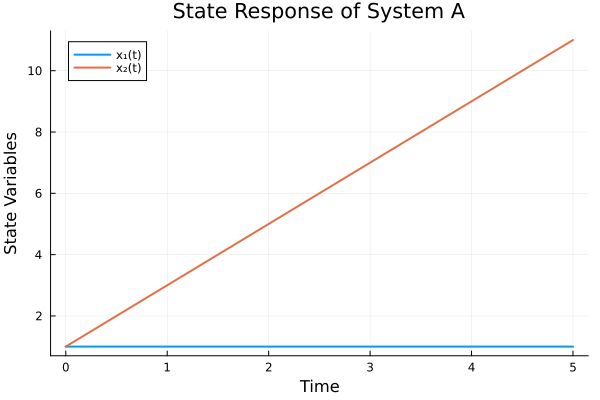

In [10]:
# Extract state variables for system A
x1_A = xt_A[:, 1]
x2_A = xt_A[:, 2]

# Plot system A
plot(t_values, x1_A, label="x₁(t)", lw=2)
plot!(t_values, x2_A, label="x₂(t)", lw=2)

xlabel!("Time")
ylabel!("State Variables")
title!("State Response of System A")
plot!(grid = true)

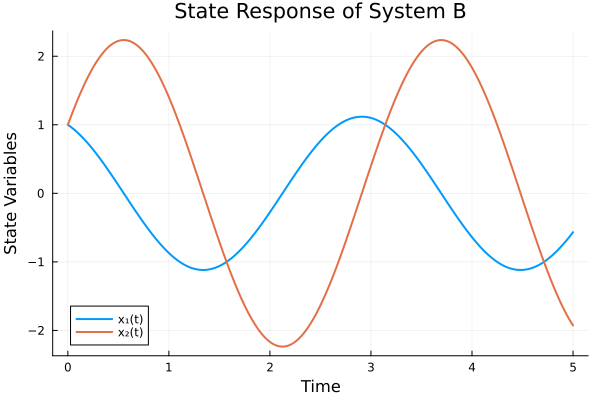

In [11]:
# Extract state variables for system B
x1_B = xt_B[:, 1]
x2_B = xt_B[:, 2]

# Plot system B
plot(t_values, x1_B, label="x₁(t)", lw=2)
plot!(t_values, x2_B, label="x₂(t)", lw=2)

xlabel!("Time")
ylabel!("State Variables")
title!("State Response of System B")
plot!(grid = true)